# Graph-DTW matching — validation report (raw vs resolved)

Validate the match results and compare **raw** (`match_routes`) against **resolved**
(`resolve_routes`, quality-filtered). Two coverage checks that should sit near **100 %**:

1. **A-edge coverage** — % of each OSM edge covered by its route (`overlap_pct`).
2. **B-edge usage** — % of each NVDB edge consumed, aggregated per NVDB edge across all routes.

Plus abnormal-case detection: under-covered A-edges, over-used / contested NVDB edges,
high-drift matches.


In [1]:
import sys, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
sys.path.append(os.path.abspath(".."))
from network_matching import DuckDBMapMatcher, setup_logging
setup_logging(log_dir="../logs", console=False)

m = DuckDBMapMatcher.from_wkt_csv("../data/osm_edges.csv", "../data/sweden_edges.csv",
        id_a="edge_id", id_b="directed_id", utm_srid=3006, max_distance=30)

# RAW result, and RESOLVED (drop high-drift / bearing-off matches)
rl_raw, rs_raw = m.match_routes(n_jobs=-1)
rs_res, rl_res = m.resolve_routes(rs_raw, rl_raw, max_match_dist=25, max_bearing_diff=45)
print(f"raw      : matched={(rs_raw.match_type!='NO_MATCH').sum()}  route-edges={len(rl_raw)}")
print(f"resolved : matched={(rs_res.match_type!='NO_MATCH').sum()}  route-edges={len(rl_res)}  "
      f"(resolve_routes: max_match_dist=25, max_bearing_diff=45)")


raw      : matched=3383  route-edges=5398
resolved : matched=2602  route-edges=4512  (resolve_routes: max_match_dist=25, max_bearing_diff=45)


## Validation function

In [2]:
def validate(rs, rl, label):
    matched = rs[rs.match_type != "NO_MATCH"]
    acov = matched["overlap_pct"].astype("float")
    bagg = (rl.groupby("dest_id")
            .agg(used=("edge_matched_len","sum"), blen=("edge_b_len","first"),
                 n_a=("source_id","nunique")).reset_index())
    bagg["used_pct"] = 100*bagg.used/bagg.blen
    d = matched["dtw_distance"]
    stats = {
        "matched A-edges":        len(matched),
        "NO_MATCH":               int((rs.match_type=="NO_MATCH").sum()),
        "A coverage median %":    round(acov.median(),1),
        "A coverage mean %":      round(acov.mean(),1),
        "A under-covered (<95%)": int((acov<95).sum()),
        "B agg-usage median %":   round(bagg.used_pct.median(),1),
        "B over-used (>110%)":    int((bagg.used_pct>110).sum()),
        "B contested (>1 A)":     int((bagg.n_a>1).sum()),
        "drift median (m)":       round(d.median(),2),
        "drift p90 (m)":          round(d.quantile(.9),2),
        "drift >10 m":            int((d>10).sum()),
        "drift >25 m":            int((d>25).sum()),
    }
    return stats, acov, bagg, d


## Side-by-side comparison: raw vs resolved

In [3]:
raw_stats,  acov_r, bagg_r, d_r = validate(rs_raw, rl_raw, "raw")
res_stats,  acov_s, bagg_s, d_s = validate(rs_res, rl_res, "resolved")
comp = pd.DataFrame({"raw": raw_stats, "resolved": res_stats})
print(comp.to_string())
display(comp)


                            raw  resolved
matched A-edges         3383.00   2602.00
NO_MATCH                 565.00   1346.00
A coverage median %      100.00    100.00
A coverage mean %         99.40     99.20
A under-covered (<95%)   116.00    116.00
B agg-usage median %     100.00    100.00
B over-used (>110%)      727.00    549.00
B contested (>1 A)      1182.00   1116.00
drift median (m)           2.64      2.10
drift p90 (m)             31.23      5.92
drift >10 m              853.00    141.00
drift >25 m              463.00      0.00


,raw,resolved
matched A-edges,3383.00,2602.00
NO_MATCH,565.00,1346.00
A coverage median %,100.00,100.00
A coverage mean %,99.40,99.20
A under-covered (<95%),116.00,116.00
B agg-usage median %,100.00,100.00
B over-used (>110%),727.00,549.00
B contested (>1 A),1182.00,1116.00
drift median (m),2.64,2.10
drift p90 (m),31.23,5.92


## Distributions — raw (blue) vs resolved (green)

Coverage/usage should pile up at ~100; resolving should thin the abnormal tails (low coverage,
over-usage, high drift).

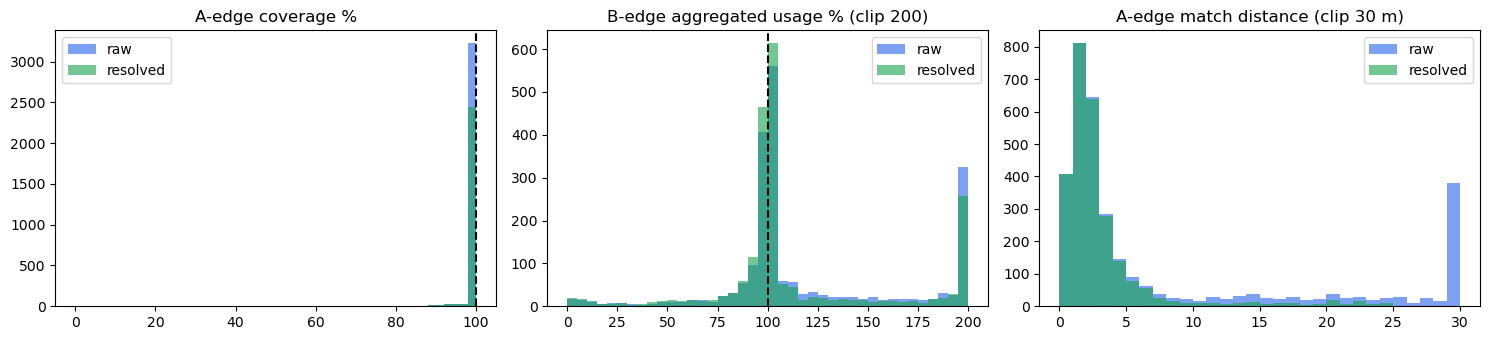

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].hist(acov_r, bins=np.arange(0,102,2), alpha=.6, label="raw", color="#2563eb")
ax[0].hist(acov_s, bins=np.arange(0,102,2), alpha=.6, label="resolved", color="#16a34a")
ax[0].axvline(100,color="k",ls="--"); ax[0].set_title("A-edge coverage %"); ax[0].legend()

ax[1].hist(bagg_r.used_pct.clip(0,200), bins=np.arange(0,205,5), alpha=.6, label="raw", color="#2563eb")
ax[1].hist(bagg_s.used_pct.clip(0,200), bins=np.arange(0,205,5), alpha=.6, label="resolved", color="#16a34a")
ax[1].axvline(100,color="k",ls="--"); ax[1].set_title("B-edge aggregated usage % (clip 200)"); ax[1].legend()

ax[2].hist(d_r.clip(0,30), bins=np.arange(0,31,1), alpha=.6, label="raw", color="#2563eb")
ax[2].hist(d_s.clip(0,30), bins=np.arange(0,31,1), alpha=.6, label="resolved", color="#16a34a")
ax[2].set_title("A-edge match distance (clip 30 m)"); ax[2].legend()
plt.tight_layout(); plt.show()


## Abnormal data in the RAW result (what resolving removes / what to review)

In [5]:
matched_raw = rs_raw[rs_raw.match_type!="NO_MATCH"]
print("Highest-drift A-edges (raw):")
display(matched_raw.sort_values("dtw_distance", ascending=False).head(8)
        [["source_id","dest_ids","dtw_distance","bearing_diff","overlap_pct","n_edges"]])
print("Most over-used / contested NVDB edges (raw):")
display(bagg_r.sort_values("used_pct", ascending=False).head(8))
print("Worst-covered A-edges (raw):")
display(matched_raw.sort_values("overlap_pct").head(8)
        [["source_id","dest_ids","overlap_pct","dtw_distance","n_edges"]])


Highest-drift A-edges (raw):


,source_id,dest_ids,dtw_distance,bearing_diff,overlap_pct,n_edges
554,634,"[918, 2105, 2106, 1746]",389.923922,74.633014,100,4
2352,2728,"[1746, 2106, 2105, 918]",381.787324,74.130781,100,4
1440,1668,[922],363.775638,3.648741,100,1
3019,3535,[2109],359.587283,3.648741,100,1
1288,1479,[2139],308.028031,60.112780,100,1
2908,3389,[2139],303.099973,60.112780,100,1
2090,2408,[2093],277.333138,30.980182,99,1
201,222,[2093],267.315899,30.724486,100,1


Most over-used / contested NVDB edges (raw):


,dest_id,used,blen,n_a,used_pct
1550,1852,347.813731,86.149333,8,403.733514
423,556,7.690609,1.922652,4,400.000000
1258,1534,5.123996,1.280999,4,400.000000
1509,1807,18.176449,4.544112,4,400.000000
1686,1998,6.976049,1.744012,4,400.000000
1169,1422,14.134846,3.533712,4,400.000000
1785,2106,115.594058,28.919639,4,399.707823
424,557,775.549363,195.191462,5,397.327504


Worst-covered A-edges (raw):


,source_id,dest_ids,overlap_pct,dtw_distance,n_edges
3345,3906,[2008],0,0.499328,1
665,757,[1246],0,0.660371,1
528,600,[2079],39,2.013272,1
2728,3168,[2278],41,2.421992,1
1864,2141,"[1745, 1746]",54,1.254755,2
2247,2604,[237],54,2.346286,1
1151,1316,"[1361, 338]",55,3.858585,2
327,379,[2467],58,0.353107,1


## Save issue lists to `output/`

In [6]:
os.makedirs("../output", exist_ok=True)
comp.to_csv("../output/validation_compare.csv")
bagg_r[bagg_r.used_pct>110].to_csv("../output/validation_b_overused_raw.csv", index=False)
matched_raw[matched_raw.dtw_distance>25].to_csv("../output/validation_high_drift_raw.csv", index=False)
print("saved: validation_compare.csv, validation_b_overused_raw.csv, validation_high_drift_raw.csv -> output/")


saved: validation_compare.csv, validation_b_overused_raw.csv, validation_high_drift_raw.csv -> output/
